# Install package

In [1]:
# !nvidia-smi

In [2]:
!pip install mat4py
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from scipy.io import loadmat
from scipy.io import savemat
import os
os.chdir('/content/drive/My Drive')

In [4]:
import collections
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import gym
import tensorflow as tf
import os
import random
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.layers import RNN
import tensorflow.keras.backend as K
import sys
from gym import spaces
from gym.utils import seeding
import copy
from mat4py import loadmat
from tensorflow.keras import layers
from tensorflow import keras
import time
np.set_printoptions(precision=16)

from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()
tf.keras.backend.set_floatx('float64')

# Environment Setup

In [5]:
# Transient Frequency Control Porblem Environment
class Transient_Frequency(gym.Env):
    def  __init__(self,M,Minv,F,D,R,Rinv,Tm,Tminv,Pl,delta_t,dim_state):
        self.param_gamma=1
        self.M=M
        self.Minv=Minv
        self.F=F
        self.D=D
        self.R=R
        self.Rinv=Rinv
        self.Tm=Tm
        self.Tminv=Tminv
        self.Pl=Pl
        self.delta_t=delta_t
        self.dim_state=dim_state
        self.viewer = None
        self.state=[]

        # self.state_transfer =  np.vstack(( np.hstack((np.identity((dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                  np.hstack((delta_t*np.identity((dim_state)), np.identity((dim_state))-delta_t*np.diag(D.reshape(dim_state,))@np.diag(Minv.reshape(dim_state,)), -delta_t*np.diag(Tminv.reshape(dim_state,))@np.diag(Rinv.reshape(dim_state,)), -delta_t*1*np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                            np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.identity((dim_state))-delta_t*np.diag(Tminv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                                   np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), delta_t*np.diag(Tminv.reshape(dim_state,)), np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
        #                                                       np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity((dim_state)))) ))

        self.state_transfer =  np.vstack(( np.hstack((np.identity((dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
                                         np.hstack((delta_t*np.identity((dim_state)), np.identity((dim_state))-delta_t*np.diag(D.reshape(dim_state,))@np.diag(Minv.reshape(dim_state,)), -delta_t*np.diag(Tminv.reshape(dim_state,))@np.diag(Rinv.reshape(dim_state,)), -delta_t*3*np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
                                                   np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.identity((dim_state))-delta_t*np.diag(Tminv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)))), \
                                                          np.hstack((np.zeros((dim_state,dim_state)), delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.identity((dim_state)), np.zeros((dim_state,dim_state)))), \
                                                              np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity((dim_state)))) ))

        self.power_injection_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.input_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), delta_t*np.identity((dim_state))))

        self.diff_mat = np.hstack((np.zeros((dim_state,dim_state)), -delta_t*np.diag(Minv.reshape(dim_state,)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        # self.gen_input_mat = np.hstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), -delta_t*np.identity((dim_state)), np.zeros((dim_state,dim_state))))

        self.select_omega = np.vstack((np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_theta = np.vstack((np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_Pm = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state))))

        self.select_Pg = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state), np.zeros((dim_state,dim_state))))

        self.select_E = np.vstack((np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)),np.zeros((dim_state,dim_state)), np.zeros((dim_state,dim_state)), np.identity(dim_state)))


    def step(self,action,Pl_change):

        theta_difference_sum =np.sum(np.sin((np.transpose(self.state@self.select_theta)@np.ones((1,dim_state)) - np.ones((dim_state,1))@(self.state@self.select_theta)))*F,axis=1)

        self.state=copy.deepcopy(self.state@self.state_transfer + (Pl+Pl_change)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat)
        return self.state

    def set_state(self, state_input):
        self.state=state_input

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [6]:
# Simulation data load from IEEE 39-bus system

data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_for_Optimal_Frequency_Control/data/IEEE_39bus_Kron.mat')

K_EN=data['Kron_39bus']['K']
K_EN=np.asarray(K_EN, dtype=np.float64)

H=data['Kron_39bus']['H']
H=np.asarray(H, dtype=np.float64)

Damp=data['Kron_39bus']['D']
Damp=np.asarray(Damp, dtype=np.float64)

omega_R=data['Kron_39bus']['omega_R']

# A_EN=data['Kron_39bus']['A']
# A_EN=np.asarray(A_EN, dtype=np.float64)

# gamma=data['Kron_39bus']['gamma']
# gamma=np.asarray(gamma, dtype=np.float64)


# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-adjacency-matrix.mat')
# C=data['D']
# C=np.asarray(C, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-power-initial-balanced.mat')
# Power_initial=data['power_initial']
# Power_initial=np.asarray(Power_initial, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-rotational-inertial-generator.mat')
# Rotational_inertial_generator=data['rotational_inertial_generator']
# Rotational_inertial_generator=np.asarray(Rotational_inertial_generator, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-rotational-inertial-load.mat')
# Rotational_inertial_load=data['rotational_inertial_load']
# Rotational_inertial_load=np.asarray(Rotational_inertial_load, dtype=np.float64)

# data = loadmat('/content/drive/MyDrive/Colab Notebooks/RL_ESS/data/IEEE-39-susceptance-matrix.mat')
# B=data['D_reactance']
# B=np.asarray(B, dtype=np.float64)

In [7]:
dim_state=10 #dimension of action space
dim_state_whole=5*dim_state #dimension of state space
action_units=dim_state
delta_t=0.01
M=H.reshape(dim_state)*2/omega_R*2*np.pi
# M[9] = .1*M[9]
Minv = 1/M
D=np.zeros(dim_state,dtype=np.float64)
D[0]=2*590/100
D[1:8]=2*865/100
D[8:10]=2*911/100
D=D/omega_R*2*np.pi
R=0.1*np.ones((1,dim_state),dtype=np.float64) #0.5
F=K_EN
Tm=7*np.ones((1,dim_state),dtype=np.float64) #7
# Tm[:,9] = 1
Rinv = 1/R
Tminv = 1/Tm
Power_initial=np.array([[0.19983394, 0.25653884, 0.25191885, 0.10242008, 0.34510365,
         -0.23206371,  -0.4404325 ,  -0.5896664 ,  -0.26257738, 0.36892462]],dtype=np.float32)
syn_frequency=-np.sum(Power_initial)/(np.sum(D) + np.sum(1/R))
Pl=copy.deepcopy(Power_initial)
Pl_nominal=copy.deepcopy(Pl)
Penalty_action= 0.2
Penalty_E= 2
equilibrium_init=np.array([[ -0.05420687, -0.07780334, -0.07351729, -0.05827823, -0.09359571,
        -0.02447385, -0.00783582,  0.00259523, -0.0162409 , -0.06477749,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.]],dtype=np.float64)
env = Transient_Frequency(M,Minv,F,D,R,Rinv,Tm,Tminv,Pl,delta_t,dim_state)

# Init Simulation

In [8]:
E_upper = .3*np.ones((1,dim_state))
E_lower = -E_upper
Pe_upper = np.abs(Power_initial)
Pe_lower = -Pe_upper

# #Linear Controller

boundary_upper=0.8*E_upper
boundary_lower=0.8*E_lower

def get_inside_bound(input,boundary_upper,boundary_lower):
    zero = tf.zeros_like(input, dtype=tf.float64)
    one = tf.ones_like(input, dtype=tf.float64)
    scale_factor_upper = tf.ones_like(input)
    scale_factor_lower = tf.ones_like(input)
    scale_factor_upper = tf.where(input <= boundary_upper, one, zero)
    scale_factor_lower = tf.where(input >= boundary_lower, one, zero)
    return scale_factor_upper*scale_factor_lower

def get_below_bound(input,boundary_lower):
    zero = tf.zeros_like(input, dtype=np.float64)
    one = tf.ones_like(input, dtype=np.float64)
    scale_factor = tf.where(input < boundary_lower, one, zero)
    return scale_factor

def get_beyond_bound(input,boundary_upper):
    zero = tf.zeros_like(input, dtype=tf.float64)
    one = tf.ones_like(input, dtype=tf.float64)
    scale_factor = tf.where(input > boundary_lower, one, zero)
    return scale_factor

slope = 0

def Action_Linear(state,env):

    states_controlled = state@env.select_omega
    states_E = state@env.select_E

    f = slope*(states_controlled)
    upper_barrier = (E_upper - states_E)/(E_upper - boundary_upper)
    lower_barrier = (states_E - E_lower)/(boundary_lower - E_lower)

    action_tempp = get_inside_bound(states_E,boundary_upper,boundary_lower)*f + get_beyond_bound(states_E,boundary_upper)*tf.math.minimum(f,upper_barrier*f) + \
                        get_below_bound(states_E,boundary_lower)*tf.math.maximum(f,lower_barrier*f)
    action_temp = tf.math.minimum(Pe_upper,action_tempp)
    action = tf.math.maximum(Pe_lower,action_temp)

    nonlinear = slope*(states_controlled)

    return nonlinear, action

#Linear case

<>:122: DeprecationWarning: invalid escape sequence '\o'
<>:132: DeprecationWarning: invalid escape sequence '\T'


array([[-0.05420687        , -0.07780334        , -0.07351729        ,
        -0.05827823        , -0.09359571        , -0.02447385        ,
        -0.00783582        ,  0.00259523        , -0.0162409         ,
        -0.06477749        ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.148866309107608 , -0.0323350818336517,
      

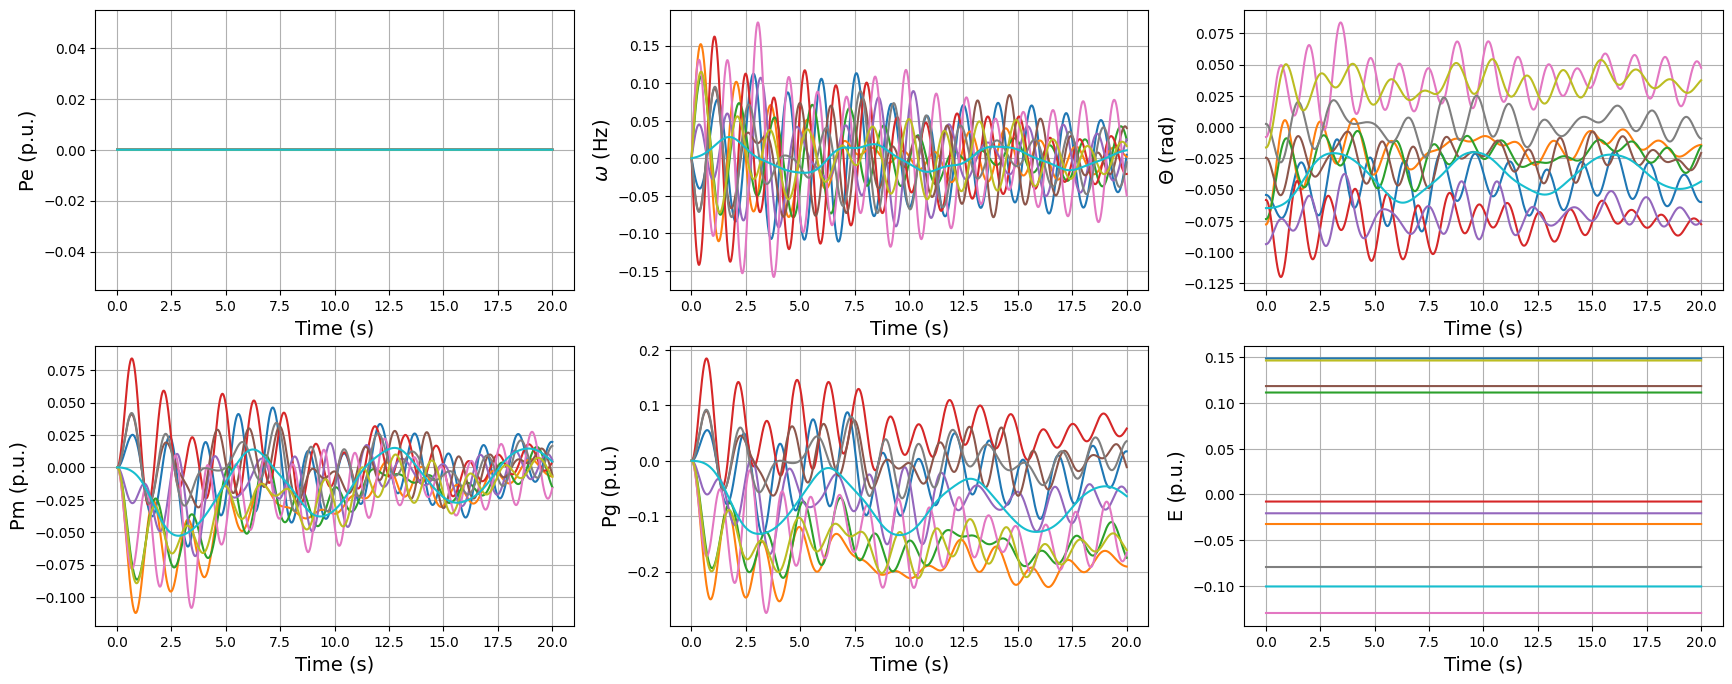

In [9]:
# Plot the trajectory to visulize the performance of control

Trajectory_Linear_omega=[]
Trajectory_Linear_omega_true=[]
Trajectory_Linear_theta=[]
Trajectory_Linear_Pm=[]
Trajectory_Linear_Pg=[]
Trajectory_Linear_E=[]

# theta_rnn_init_bound=0.05
# omega_rnn_init_bound=0.1 #in Hz
# Pm_rnn_init_bound=0
# E_rnn_init_bound=0*E_upper

theta_rnn_init_bound=0.05*0
omega_rnn_init_bound=0.1*0 #in Hz
Pm_rnn_init_bound=0.05*0
Pg_rnn_init_bound=0
E_rnn_init_bound= .5*E_upper

s_concate = np.zeros((1,5*dim_state))

initial_state1= np.random.uniform(-theta_rnn_init_bound,theta_rnn_init_bound,(1,dim_state))
initial_state2= np.random.uniform(-omega_rnn_init_bound,omega_rnn_init_bound,(1,dim_state))
initial_state3= np.random.uniform(-Pm_rnn_init_bound,Pm_rnn_init_bound,(1,dim_state))
initial_state4= np.random.uniform(-Pg_rnn_init_bound,Pg_rnn_init_bound,(1,dim_state))
initial_state5= np.random.uniform(-E_rnn_init_bound,E_rnn_init_bound,(1,dim_state))
s_concate=np.hstack((initial_state1,initial_state2,initial_state3,initial_state4,initial_state5)).astype(np.float64)

init_state=s_concate + equilibrium_init

#
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_theta = s@env.select_theta
s_record_all_Pm = s@env.select_Pm
s_record_all_Pg = s@env.select_Pg
s_record_all_E = s@env.select_E
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))

env.set_state(s)
Trajectory_Linear_omega.append(s_record_all_omega)
Trajectory_Linear_theta.append(s_record_all_theta)
Trajectory_Linear_omega_true.append(s_record_all_omega_true)
Trajectory_Linear_Pm.append(s_record_all_Pm)
Trajectory_Linear_Pg.append(s_record_all_Pg)
Trajectory_Linear_E.append(s_record_all_E)

Test_time=20
Train_time=5

SimulationLength=int(Test_time/delta_t)
Record_u_Linear=[]
Record_e_Linear=[]
Loss_Linear=0

# generator_loss_node = np.arange(dim_state)  ## -1
Pl_change_test = np.zeros((1,dim_state))

# generator_loss_start_time = 0
# generator_loss_period = 10

# Pl_change_test = 1*np.random.uniform(-1,1,dim_state)  # np.random.uniform(-1,1,4)*2 #-Pl_nominal[0,generator_loss_node]

Pl_change_test = np.array([[ 0.2340710641071226, -0.5867602762801327, -0.4561132718248471,
        0.6271401105973777, -0.1808982288146022,  0.3780068723952434,
       -0.5433232759085382,  0.2702496806181285, -0.4870327862385655,
       -0.1166459469537584]], dtype=np.float64)

# Pl_change_test = 0.3*np.array([[-0.8905491129973098, -0.4424022836421031, -0.945952470869504,
#   -0.4609707306414945,  0.8244178919743579,  0.2138969034820994,
#   -0.3140688381736034, -0.8510438994530267,  0.8778295889243362,
#    0.2575727076764531]],dtype=np.float64)

for i in range(SimulationLength):

    e,u=Action_Linear(s,env)
    next_s= env.step(u,Pl_change_test)
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_theta = s@env.select_theta
    s_record_all_Pm = s@env.select_Pm
    s_record_all_Pg = s@env.select_Pg
    s_record_all_E = s@env.select_E
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))
    Trajectory_Linear_omega.append(s_record_all_omega)
    Trajectory_Linear_theta.append(s_record_all_theta)
    Trajectory_Linear_omega_true.append(s_record_all_omega_true)
    Trajectory_Linear_Pm.append(s_record_all_Pm)
    Trajectory_Linear_Pg.append(s_record_all_Pg)
    Trajectory_Linear_E.append(s_record_all_E)
    Record_e_Linear.append(e)
    Record_u_Linear.append(u)

Trajectory_Linear_omega=np.squeeze(np.asarray(Trajectory_Linear_omega))
Trajectory_Linear_theta=np.squeeze(np.asarray(Trajectory_Linear_theta))
Trajectory_Linear_Pm=np.squeeze(np.asarray(Trajectory_Linear_Pm))
Trajectory_Linear_Pg=np.squeeze(np.asarray(Trajectory_Linear_Pg))
Trajectory_Linear_E=np.squeeze(np.asarray(Trajectory_Linear_E))
Trajectory_Linear_omega_true=np.squeeze(np.asarray(Trajectory_Linear_omega_true))
Record_u_Linear=np.squeeze(np.asarray(Record_u_Linear))
Record_e_Linear=np.squeeze(np.asarray(Record_e_Linear))

plt.figure(figsize=(21,8), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(2,3,1)

plt.plot(TimeRecord,Record_u_Linear)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pe (p.u.)', fontsize=14)


plt.subplot(2,3,2)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_omega)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (Hz)', fontsize=14)


plt.subplot(2,3,3)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_theta)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\Theta$ (rad)', fontsize=14)


plt.subplot(2,3,4)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_Pm)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pm (p.u.)', fontsize=14)

plt.subplot(2,3,5)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_Pg)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pg (p.u.)', fontsize=14)

plt.subplot(2,3,6)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_Linear_E)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('E (p.u.)', fontsize=14)

init_state

In [10]:
Penalty_action*np.sum(np.power(Record_u_Linear,2))/(Test_time/delta_t) + np.sum(np.max(np.abs(Trajectory_Linear_omega),0)) + Penalty_E*np.sum(np.power(Trajectory_Linear_E[int(Test_time/delta_t-1),:],2))

1.367256517957455

In [11]:
Penalty_action*np.sum(np.power(Record_u_Linear,2))/(Test_time/delta_t)

0.0

In [12]:
np.sum(np.max(np.abs(Trajectory_Linear_omega),0))

1.1573010813214355

In [13]:
Penalty_E*np.sum(np.power(Trajectory_Linear_E[int(Test_time/delta_t-1),:],2),0)

0.20995543663601934

# RNN

In [14]:
# RNN Cell to integrate state transition dynamics

class MinimalRNNCell(keras.layers.Layer):

    def __init__(self,units,action_units,internal_units,env,batchsize,**kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize=batchsize
        self.state_transfer=tf.constant(env.state_transfer,dtype=tf.float64)
        self.power_injection_mat=tf.constant(env.power_injection_mat,dtype=tf.float64)
        self.input_mat=tf.constant(env.input_mat,dtype=tf.float64)
        self.diff_mat=tf.constant(env.diff_mat,dtype=tf.float64)
        self.select_omega=tf.constant(env.select_omega,dtype=tf.float64)
        self.select_theta=tf.constant(env.select_theta,dtype=tf.float64)
        self.select_E=tf.constant(env.select_E,dtype=tf.float64)
        self.Multiply_ones=tf.tile(tf.ones((action_units,action_units),dtype=np.float64)[None], [batchsize, 1, 1])
        self.weight_recover=tf.constant(tf.linalg.band_part(-tf.ones((internal_units,internal_units),dtype=tf.float64),0,1)\
                                        +2*tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.bias_recover=tf.constant(tf.linalg.band_part(tf.ones((internal_units,internal_units),dtype=tf.float64),0,-1)\
                                        -tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.ones_frequency=tf.ones((action_units,internal_units),dtype=np.float64)
        super(MinimalRNNCell, self).__init__(**kwargs)

    def build(self, input_shape):

        self.ke_temp = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='ke_temp')

        self.w_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='w')

        self.b_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.5),
            name='b')

        self.d = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='d')

        self.built = True

    def call(self, inputs, states):

        # change of power injection
        global count_num

        prev_output = states[0]
        states_controlled = K.dot(prev_output,self.select_omega)

        # stacked ReLU structure to represent control network

        ke_upper = (Pe_upper - Pe_lower)/(E_upper - E_lower)

        ke_temp = tf.math.minimum(tf.math.abs(self.ke_temp),2*D.reshape(self.action_units,))

        ke = tf.math.minimum(ke_temp,ke_upper)

        slope_upper = (ke + tf.sqrt(2*ke*D.reshape(self.action_units,)))/ke
        slope_lower = (ke - tf.sqrt(2*ke*D.reshape(self.action_units,)))/ke

        slope_upper_mat = K.dot(slope_upper.reshape(self.action_units,1),tf.ones((1,self.internal_units),dtype=tf.float64))
        slope_lower_mat = K.dot(slope_lower.reshape(self.action_units,1),tf.ones((1,self.internal_units),dtype=tf.float64))

        w_temp = tf.math.maximum(tf.math.minimum(self.w_temp,slope_upper_mat),slope_lower_mat)

        w=K.dot(w_temp,self.weight_recover)
        b=tf.sort(self.b_temp,axis=-1,direction='DESCENDING')
        d=self.d

        nonlinear_temp = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b)*w,axis=2) + d

        nonlinear_upper = tf.math.minimum(E_lower + Pe_upper/ke, E_upper)
        nonlinear_lower = tf.math.maximum(E_upper + Pe_lower/ke, E_lower)
        nonlinear = tf.math.minimum(tf.math.maximum(nonlinear_temp,nonlinear_lower),nonlinear_upper)

        action = ke*(nonlinear - K.dot(prev_output,self.select_E))

        # integrate the state transition dynamics
        theta_difference_sum = K.sum((tf.matmul(tf.linalg.diag(K.dot(prev_output, self.select_theta)),self.Multiply_ones)-\
                                tf.matmul(self.Multiply_ones,tf.linalg.diag(K.dot(prev_output, self.select_theta))))*F,axis=2)

        new_state = prev_output@self.state_transfer + (Pl + inputs)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat

        frequency=K.dot(new_state,self.select_omega)
        E=K.dot(new_state,self.select_E)

        count_num+=1
        if count_num == T-1:
          print("One Episode Ended")
          count_num=0

        return [frequency,action,E,nonlinear], [new_state]

class MinimalRNNCell_New(keras.layers.Layer):

    def __init__(self,units,action_units,internal_units,env,batchsize,**kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize=batchsize
        self.state_transfer=tf.constant(env.state_transfer,dtype=tf.float64)
        self.power_injection_mat=tf.constant(env.power_injection_mat,dtype=tf.float64)
        self.input_mat=tf.constant(env.input_mat,dtype=tf.float64)
        self.diff_mat=tf.constant(env.diff_mat,dtype=tf.float64)
        self.select_omega=tf.constant(env.select_omega,dtype=tf.float64)
        self.select_theta=tf.constant(env.select_theta,dtype=tf.float64)
        self.select_E=tf.constant(env.select_E,dtype=tf.float64)
        self.Multiply_ones=tf.tile(tf.ones((action_units,action_units),dtype=np.float64)[None], [batchsize, 1, 1])
        self.w_recover=tf.constant(tf.linalg.band_part(-tf.ones((internal_units,internal_units),dtype=tf.float64),0,1)\
                                        +2*tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.b_recover=tf.constant(tf.linalg.band_part(tf.ones((internal_units,internal_units),dtype=tf.float64),0,-1)\
                                        -tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.ones_frequency=tf.ones((action_units,internal_units),dtype=np.float64)
        super(MinimalRNNCell_New, self).__init__(**kwargs)

    def build(self, input_shape):

        self.w_plus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            # initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
            trainable=True,
            name='w_plus_temp')

        self.b_plus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            # initializer='uniform',
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.02),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.02),
            name='b_plus_temp')
        self.w_minus_temp0= self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            # initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
            trainable=True,
            name='w_minus_temp')

        self.b_minus_temp0 = self.add_weight(
            shape=(self.action_units,self.internal_units),
            # initializer='uniform',
            initializer=tf.keras.initializers.RandomUniform(minval=0, maxval=0.02),
            trainable=True,
            constraint=tf.keras.constraints.MaxNorm(0.02),
            name='b_minus_temp')

        self.thr_upper_temp = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='thr_upper_temp')

        self.thr_lower_temp = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='thr_lower_temp')

        self.built = True

    def call(self, inputs, states):

        prev_output = states[0]
        states_controlled = K.dot(prev_output,self.select_omega)
        states_E = K.dot(prev_output,self.select_E)

        # stacked ReLU structure to represent control network

        w_plus_temp=tf.math.abs(self.w_plus_temp0)
        b_plus_temp=tf.math.abs(self.b_plus_temp0)
        w_minus_temp=tf.math.abs(self.w_minus_temp0)
        b_minus_temp=tf.math.abs(self.b_minus_temp0)
        w_plus=K.dot(w_plus_temp,self.w_recover)
        b_plus=K.dot(-b_plus_temp,self.b_recover)
        w_minus=K.dot(-w_minus_temp,self.w_recover)
        b_minus=K.dot(-b_minus_temp,self.b_recover)

        thr_lower = K.sigmoid(self.thr_lower_temp)
        thr_upper = K.sigmoid(self.thr_upper_temp)

        nonlinear_plus=K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b_plus)\
                        *w_plus,axis=2)   #gamma
        nonlinear_minus=K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b_minus)\
                        *w_minus,axis=2)

        f = (nonlinear_plus + nonlinear_minus)

        boundary_upper=thr_upper*E_upper
        boundary_lower=thr_lower*E_lower

        upper_barrier = (E_upper - states_E)/(E_upper - thr_upper*E_upper)
        lower_barrier = (states_E - E_lower)/(thr_lower*E_lower - E_lower)

        action_nonconstrain = get_inside_bound(states_E,thr_upper*E_upper,thr_upper*E_upper)*f + get_beyond_bound(states_E,thr_upper*E_upper)*tf.math.minimum(f,upper_barrier*f) + \
                        get_below_bound(states_E,thr_lower*E_lower)*tf.math.maximum(f,lower_barrier*f)


        nonlinear = (nonlinear_plus + nonlinear_minus)

        action = tf.math.minimum(tf.math.maximum(action_nonconstrain,Pe_lower),Pe_upper)

        # integrate the state transition dynamics

        theta_difference_sum = K.sum(tf.math.sin(tf.matmul(tf.linalg.diag(K.dot(prev_output, self.select_theta)),self.Multiply_ones)-\
                                tf.matmul(self.Multiply_ones,tf.linalg.diag(K.dot(prev_output, self.select_theta))))*F,axis=2)

        new_state = prev_output@self.state_transfer + (Pl + inputs)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat

        frequency=K.dot(new_state,self.select_omega)
        E=K.dot(new_state,self.select_E)

        return [frequency,action,E,nonlinear], [new_state]

class MinimalRNNCell_Free(keras.layers.Layer):

    def __init__(self,units,action_units,internal_units,env,batchsize,**kwargs):
        self.units = units
        self.state_size = units
        self.action_units = action_units
        self.internal_units = internal_units
        self.batchsize=batchsize
        self.state_transfer=tf.constant(env.state_transfer,dtype=tf.float64)
        self.power_injection_mat=tf.constant(env.power_injection_mat,dtype=tf.float64)
        self.input_mat=tf.constant(env.input_mat,dtype=tf.float64)
        self.diff_mat=tf.constant(env.diff_mat,dtype=tf.float64)
        self.select_omega=tf.constant(env.select_omega,dtype=tf.float64)
        self.select_theta=tf.constant(env.select_theta,dtype=tf.float64)
        self.select_E=tf.constant(env.select_E,dtype=tf.float64)
        self.Multiply_ones=tf.tile(tf.ones((action_units,action_units),dtype=tf.float64)[None], [batchsize, 1, 1])
        self.w_recover=tf.constant(tf.linalg.band_part(-tf.ones((internal_units,internal_units),dtype=tf.float64),0,1)\
                                        +2*tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.b_recover=tf.constant(tf.linalg.band_part(tf.ones((internal_units,internal_units),dtype=tf.float64),0,-1)\
                                        -tf.eye(internal_units,dtype=tf.float64),dtype=tf.float64)
        self.ones_frequency=tf.ones((action_units,internal_units),dtype=np.float64)
        super(MinimalRNNCell_Free, self).__init__(**kwargs)

    def build(self, input_shape):


        self.w_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer=tf.keras.initializers.RandomUniform(minval=-1, maxval=1),
            trainable=True,
            name='w')

        self.b_temp = self.add_weight(
            shape=(self.action_units,self.internal_units),
            initializer='uniform',
            trainable=True,
            name='b')

        self.d = self.add_weight(
            shape=(self.action_units,),
            initializer='uniform',
            trainable=True,
            name='d')

        self.built = True

    def call(self, inputs, states):

        # change of power injection
        global count_num

        prev_output = states[0]
        states_controlled = K.dot(prev_output,self.select_omega)
        states_E = K.dot(prev_output,self.select_E)

        # stacked ReLU structure to represent control network

        w=self.w_temp
        b=self.b_temp
        d=self.d

        nonlinear_nonconstrain = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),self.ones_frequency)+b)*w,axis=2) + d

        # f = (nonlinear_plus + nonlinear_minus)
        # upper_barrier = (E_upper - states_E)/(E_upper - 0.9*E_upper)
        # lower_barrier = (states_E - E_lower)/(0.9*E_lower - E_lower)

        # action_nonconstrain = get_inside_bound(states_E)*f + get_beyond_bound(states_E)*tf.math.minimum(f,upper_barrier*f) + \
        #                 get_below_bound(states_E)*tf.math.maximum(f,lower_barrier*f)


        nonlinear = tf.math.minimum(tf.math.maximum(nonlinear_nonconstrain,Pe_lower),Pe_upper)


        condition = tf.math.logical_or(tf.math.logical_and(tf.math.less(E_upper , states_E),tf.math.less(tf.zeros((1,dim_state),dtype=tf.float64),nonlinear)), \
                                       tf.math.logical_and(tf.math.less(states_E , E_lower),tf.math.less(nonlinear,tf.zeros((1,dim_state),dtype=tf.float64))))
        action = tf.where(condition, tf.zeros_like(nonlinear), nonlinear)

        # integrate the state transition dynamics

        theta_difference_sum = K.sum((tf.matmul(tf.linalg.diag(K.dot(prev_output, self.select_theta)),self.Multiply_ones)-\
                                tf.matmul(self.Multiply_ones,tf.linalg.diag(K.dot(prev_output, self.select_theta))))*F,axis=2)

        new_state = prev_output@self.state_transfer + (Pl + inputs)@self.power_injection_mat + action@self.input_mat + theta_difference_sum@self.diff_mat

        frequency=K.dot(new_state,self.select_omega)
        E=K.dot(new_state,self.select_E)

        return [frequency,action,E,nonlinear], [new_state]



In [15]:
start = time.time()

episodes = 100 # total number of iterations to update weights
units=dim_state_whole
action_units=dim_state
internal_units=50 # demension of the neural network for control policy
T=500  #Total period considered
Batch_num=600 # number of batch in each episodes 60
#loss_distribution=np.ones((Batch_num,dim_omega), dtype=np.float64)
cell = MinimalRNNCell_New(units,action_units,internal_units,env,Batch_num)
layer = RNN(cell,return_sequences=True,stateful = True)
input_1 = tf.keras.Input(batch_input_shape=(Batch_num,T,action_units))
outputs = layer((input_1))
model = tf.keras.models.Model([input_1], outputs)
model.compile(optimizer='Adam', loss='mse', metrics=['accuracy'])

x0=np.ones((Batch_num,T,action_units))
y0=model(x0)
Loss_record=[]
Pe_rnn_record=[]
global_step = tf.Variable(0, trainable=False)
learning_rate_initial=0.1
decayed_lr =tf.keras.optimizers.schedules.ExponentialDecay(
    learning_rate_initial, 20, 0.7, staircase=True)
optimizer=tf.keras.optimizers.Adam(learning_rate=decayed_lr)

PrintUpdate=1

num_gen_step = 10 #np.arange(dim_state)
Percent_step_change = 1
range_step_change = 1


for i in range(0,episodes):
    initial_state1=np.random.uniform(-theta_rnn_init_bound,theta_rnn_init_bound,(Batch_num,dim_state))
    initial_state2=np.random.uniform(-omega_rnn_init_bound,omega_rnn_init_bound,(Batch_num,dim_state))
    initial_state3=np.random.uniform(-Pm_rnn_init_bound,Pm_rnn_init_bound,(Batch_num,dim_state))
    initial_state4=np.random.uniform(-Pg_rnn_init_bound,Pg_rnn_init_bound,(Batch_num,dim_state))
    initial_state5=np.random.uniform(-E_rnn_init_bound,E_rnn_init_bound,(Batch_num,dim_state))
    initial_state=np.hstack((initial_state1,initial_state2,initial_state3,initial_state4,initial_state5))+equilibrium_init

    Pl_change = np.zeros((Batch_num,T,action_units))
    for gen_interupt in range(0, num_gen_step):
      idx_gen_deviation =  np.random.randint(0, action_units, Batch_num*Percent_step_change) #(num_gen_step[gen_interupt])*np.ones((Batch_num,),dtype=np.int32)
      idx_batch_deviation = np.random.randint(0, Batch_num, Batch_num*Percent_step_change)  #np.arange(Batch_num)
      step_change = np.random.uniform(-1,1,(Batch_num*Percent_step_change))*range_step_change #[gen_interupt]
      for t_interupt in range(0,T):
          Pl_change[idx_batch_deviation,t_interupt,idx_gen_deviation] = step_change

    layer.reset_states(initial_state)
    with tf.GradientTape(persistent=True) as tape:
        [frequency,action,E,nonlinear]=model(Pl_change)
        loss=Penalty_action*K.sum(K.pow(action,2))/(Batch_num*T) + K.sum(K.max(K.abs(frequency),axis=1))/Batch_num + Penalty_E*K.sum(K.pow(E[:,int(T-1),:],2))/Batch_num
        #10*(K.sum(K.pow(nonlinear,2))+
    grads = tape.gradient(loss, model.variables)
    optimizer.apply_gradients(zip(grads, model.variables))
    Loss_record.append(loss)
    if i % (PrintUpdate) == 0:
        print('episode',i, 'Loss',loss)
        print('episode',i, 'Loss_frequency', (K.sum(K.max(K.abs(frequency),axis=1)))/Batch_num)
        print('episode',i, 'Loss_action', (Penalty_action*K.sum(K.pow(action,2)))/(Batch_num*T))
        print('episode',i, 'Loss_E', (Penalty_E*K.sum(K.pow(E[:,int(T-1),:],2)))/Batch_num)
        print()

end = time.time()
print(end - start)

episode 0 Loss tf.Tensor(1.2963459007460656, shape=(), dtype=float64)
episode 0 Loss_frequency tf.Tensor(1.1405741133706093, shape=(), dtype=float64)
episode 0 Loss_action tf.Tensor(1.3862812916599455e-05, shape=(), dtype=float64)
episode 0 Loss_E tf.Tensor(0.15575792456253953, shape=(), dtype=float64)

episode 1 Loss tf.Tensor(1.2162130201714594, shape=(), dtype=float64)
episode 1 Loss_frequency tf.Tensor(1.0317127088757836, shape=(), dtype=float64)
episode 1 Loss_action tf.Tensor(0.000318231683993521, shape=(), dtype=float64)
episode 1 Loss_E tf.Tensor(0.18418207961168218, shape=(), dtype=float64)

episode 2 Loss tf.Tensor(1.1599030736687943, shape=(), dtype=float64)
episode 2 Loss_frequency tf.Tensor(0.9553913155823269, shape=(), dtype=float64)
episode 2 Loss_action tf.Tensor(0.000788003495362134, shape=(), dtype=float64)
episode 2 Loss_E tf.Tensor(0.2037237545911052, shape=(), dtype=float64)

episode 3 Loss tf.Tensor(1.1154899051159104, shape=(), dtype=float64)
episode 3 Loss_frequ

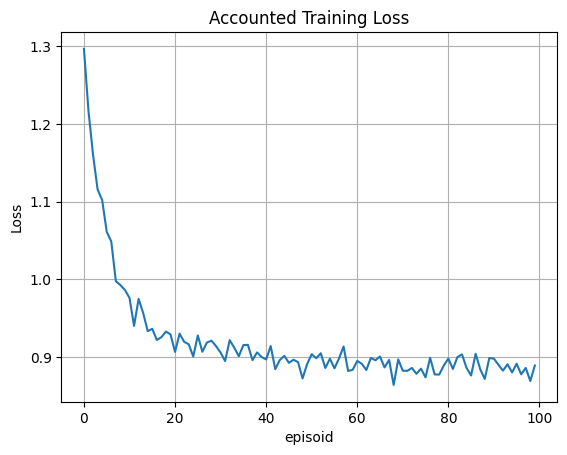

In [16]:
plt.plot(Loss_record)
plt.xlabel('episoid')
plt.ylabel('Loss')
plt.grid()
plt.title('Accounted Training Loss')
# file_name='Loss_ESS_wo_regu.mat'
file_name='Loss_ESS_w_regu.mat'
# file_name='Loss_ESS_Free.mat'
savemat(file_name,{'Loss_record':Loss_record})

In [17]:
from scipy.io import loadmat
from scipy.io import savemat


# w=(model.variables[0]).numpy()
# b=(model.variables[1]).numpy()
# d=(model.variables[2]).numpy()

# file_name='optimal_controllers_Free.mat'
# savemat(file_name,{'w':w,'b':b,'d':d})


w_plus_temp=tf.math.abs(model.variables[0])
b_plus_temp=tf.math.abs(model.variables[1])
w_minus_temp=tf.math.abs(model.variables[2])
b_minus_temp=tf.math.abs(model.variables[3])

w_plus=(K.dot(w_plus_temp,cell.w_recover)).numpy()
b_plus=(K.dot(-b_plus_temp,cell.b_recover)).numpy()
w_minus=(K.dot(-w_minus_temp,cell.w_recover)).numpy()
b_minus=(K.dot(-b_minus_temp,cell.b_recover)).numpy()

thr_upper = (K.sigmoid(model.variables[4])).numpy()
thr_lower = (K.sigmoid(model.variables[5])).numpy()

#file_name='optimal_controllers_ESS_wo_regu.mat'
file_name='optimal_controllers_ESS_w_regu.mat'
savemat(file_name,{'w_plus':w_plus,'b_plus':b_plus,'w_minus':w_minus,'b_minus':b_minus,'thr_upper':thr_upper,'thr_lower':thr_lower})

In [18]:
# print(w_plus)
# print(b_minus)

In [19]:
# print(thr_lower)

In [20]:
# print(thr_upper)

# Simulate

In [21]:
# def Action(state,env):

#     states_controlled = state@cell.select_omega
#     states_E = state@cell.select_E

#     nonlinear_nonconstrain = K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),cell.ones_frequency)+b)*w,axis=2) + d

#     nonlinear = tf.math.minimum(tf.math.maximum(nonlinear_nonconstrain, Pe_lower), Pe_upper)

#     condition = tf.math.logical_or(tf.math.logical_and(tf.math.less(E_upper , states_E),tf.math.less(tf.zeros((1,dim_state),dtype=tf.float64),nonlinear)), \
#                                        tf.math.logical_and(tf.math.less(states_E , E_lower),tf.math.less(nonlinear,tf.zeros((1,dim_state),dtype=tf.float64))))

#     action = tf.where(condition, tf.zeros_like(nonlinear), nonlinear)

#     return nonlinear_nonconstrain, action


def Action(state,env):

    states_controlled = state@cell.select_omega
    states_E = state@cell.select_E

    nonlinear_plus=K.sum(K.relu(K.dot(tf.linalg.diag(states_controlled),cell.ones_frequency)+b_plus)\
                    *w_plus,axis=2)
    nonlinear_minus=K.sum(K.relu(-K.dot(tf.linalg.diag(states_controlled),cell.ones_frequency)+b_minus)\
                    *w_minus,axis=2)

    f = (nonlinear_plus + nonlinear_minus)
    upper_barrier = (E_upper - states_E)/(E_upper - thr_upper*E_upper)
    lower_barrier = (states_E - E_lower)/(thr_lower*E_lower - E_lower)

    action_nonconstrain = get_inside_bound(states_E,thr_upper*E_upper,thr_upper*E_upper)*f + get_beyond_bound(states_E,thr_upper*E_upper)*tf.math.minimum(f,upper_barrier*f) + \
                        get_below_bound(states_E,thr_lower*E_lower)*tf.math.maximum(f,lower_barrier*f)

    action = tf.math.minimum(tf.math.maximum(action_nonconstrain,Pe_lower),Pe_upper)

    nonlinear = nonlinear_plus + nonlinear_minus

    return nonlinear, action

array([[-0.05420687        , -0.07780334        , -0.07351729        ,
        -0.05827823        , -0.09359571        , -0.02447385        ,
        -0.00783582        ,  0.00259523        , -0.0162409         ,
        -0.06477749        ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.                ,  0.                ,
         0.                ,  0.148866309107608 , -0.0323350818336517,
      

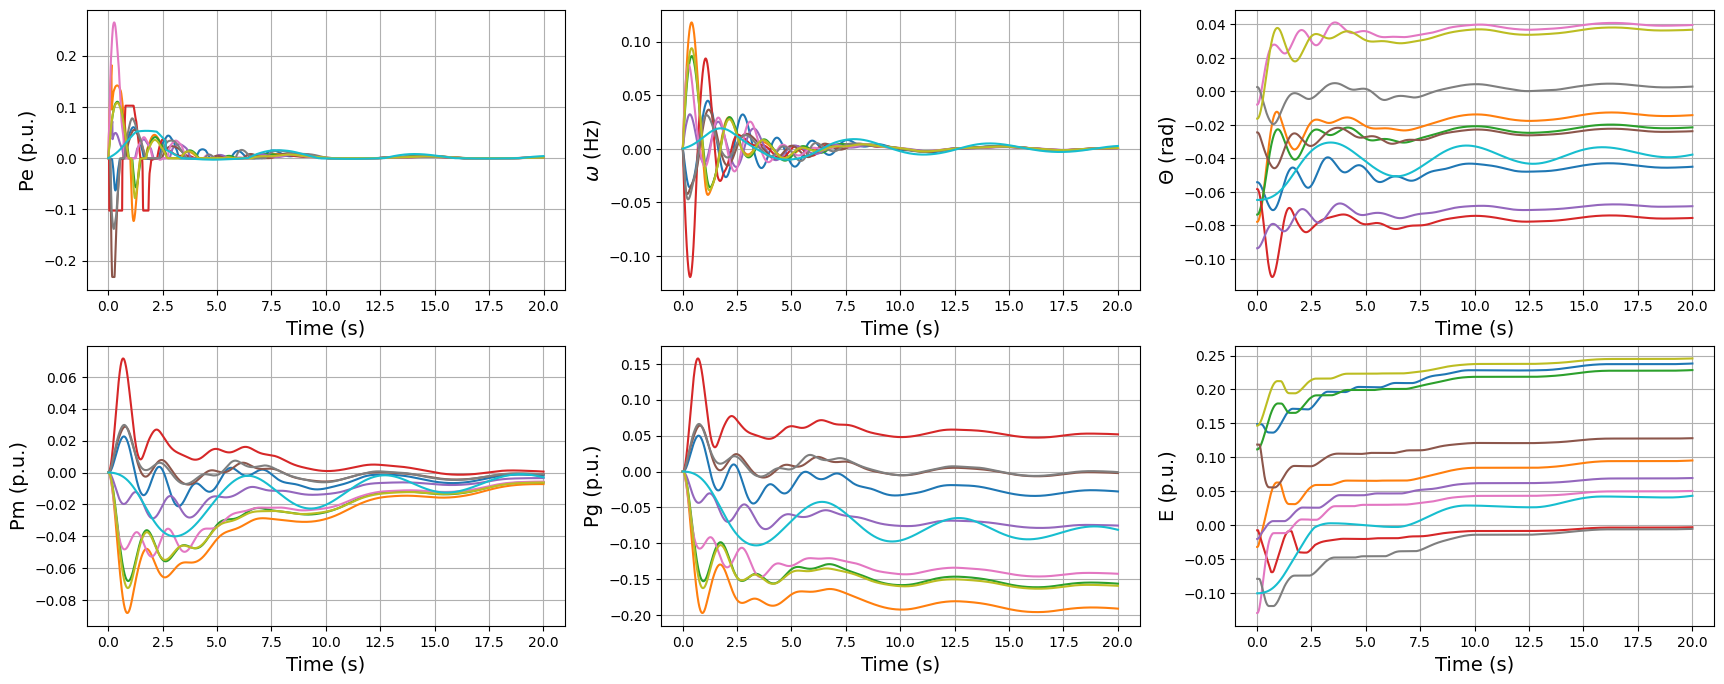

In [22]:
# Plot the trajectory to visulize the performance of control

Trajectory_RNN_omega=[]
Trajectory_RNN_omega_true=[]
Trajectory_RNN_theta=[]
Trajectory_RNN_Pm=[]
Trajectory_RNN_Pg=[]
Trajectory_RNN_E=[]

# theta_rnn_init_bound=0.05
# omega_rnn_init_bound=0.1 #in Hz
# Pm_rnn_init_bound=0.5
# E_rnn_init_bound=E_upper

# s_concate = np.zeros((1,4*dim_state))

# initial_state1= np.random.uniform(-theta_rnn_init_bound,theta_rnn_init_bound,(1,dim_state))
# initial_state2= np.random.uniform(-omega_rnn_init_bound,omega_rnn_init_bound,(1,dim_state))
# initial_state3= np.random.uniform(-Pm_rnn_init_bound,Pm_rnn_init_bound,(1,dim_state))
# initial_state4= np.random.uniform(-E_rnn_init_bound,E_rnn_init_bound,(1,dim_state))
# s_concate=np.hstack((initial_state1,initial_state2,initial_state3,initial_state4)).astype(np.float64)

# Pl_change_test[0,generator_loss_node] = np.random.uniform(-1,1,dim_state)  # np.random.uniform(-1,1,4)*2 #-Pl_nominal[0,generator_loss_node]

init_state=s_concate+equilibrium_init
#
s=init_state
s_record_all_omega = s@env.select_omega
s_record_all_theta = s@env.select_theta
s_record_all_Pm = s@env.select_Pm
s_record_all_Pg = s@env.select_Pg
s_record_all_E = s@env.select_E
s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))

env.set_state(s)
Trajectory_RNN_omega.append(s_record_all_omega)
Trajectory_RNN_theta.append(s_record_all_theta)
Trajectory_RNN_omega_true.append(s_record_all_omega_true)
Trajectory_RNN_Pm.append(s_record_all_Pm)
Trajectory_RNN_Pg.append(s_record_all_Pg)
Trajectory_RNN_E.append(s_record_all_E)

Test_time=20
SimulationLength=int(Test_time/delta_t)
Record_u_RNN=[]
Record_e_RNN=[]

# generator_loss_start_time = 0
# generator_loss_period = 50

for i in range(SimulationLength):
    # if i>=generator_loss_start_time/delta_t and i<=(generator_loss_start_time+generator_loss_period)/delta_t:
    #   Pl[0,generator_loss_node] = 0
    # else:
    #   Pl[0,generator_loss_node] = Pl_nominal[0,generator_loss_node]
    # Pl[0,generator_loss_node] = 0 #-Pl_nominal[0,generator_loss_node]
    e,u=Action(s,env)
    next_s= env.step(u,Pl_change_test)
    s=next_s
    s_record_all_omega = s@env.select_omega
    s_record_all_theta = s@env.select_theta
    s_record_all_Pm = s@env.select_Pm
    s_record_all_Pg = s@env.select_Pg
    s_record_all_E = s@env.select_E
    s_record_all_omega_true = s_record_all_omega + 60*np.ones((1,dim_state))
    Trajectory_RNN_omega.append(s_record_all_omega)
    Trajectory_RNN_theta.append(s_record_all_theta)
    Trajectory_RNN_omega_true.append(s_record_all_omega_true)
    Trajectory_RNN_Pm.append(s_record_all_Pm)
    Trajectory_RNN_Pg.append(s_record_all_Pg)
    Trajectory_RNN_E.append(s_record_all_E)
    Record_e_RNN.append(e)
    Record_u_RNN.append(u)

Trajectory_RNN_omega=np.squeeze(np.asarray(Trajectory_RNN_omega))
Trajectory_RNN_theta=np.squeeze(np.asarray(Trajectory_RNN_theta))
Trajectory_RNN_Pm=np.squeeze(np.asarray(Trajectory_RNN_Pm))
Trajectory_RNN_Pg=np.squeeze(np.asarray(Trajectory_RNN_Pg))
Trajectory_RNN_E=np.squeeze(np.asarray(Trajectory_RNN_E))
Trajectory_RNN_omega_true=np.squeeze(np.asarray(Trajectory_RNN_omega_true))
Record_u_RNN=np.squeeze(np.asarray(Record_u_RNN))
Record_e_RNN=np.squeeze(np.asarray(Record_e_RNN))

plt.figure(figsize=(21,8), dpi=100)
TimeRecord=np.arange(1,SimulationLength+1)
TimeRecord=env.delta_t*TimeRecord
plt.subplot(2,3,1)

plt.plot(TimeRecord,Record_u_RNN)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pe (p.u.)', fontsize=14)


plt.subplot(2,3,2)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_omega)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\omega$ (Hz)', fontsize=14)

plt.subplot(2,3,3)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord


plt.plot(TimeRecord,Trajectory_RNN_theta)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('$\Theta$ (rad)', fontsize=14)

plt.subplot(2,3,4)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_Pm)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pm (p.u.)', fontsize=14)

plt.subplot(2,3,5)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_Pg)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('Pg (p.u.)', fontsize=14)

plt.subplot(2,3,6)
TimeRecord=np.arange(1,SimulationLength+2)
TimeRecord=env.delta_t*TimeRecord

plt.plot(TimeRecord,Trajectory_RNN_E)
plt.grid()
plt.xlabel('Time (s)', fontsize=14)
plt.ylabel('E (p.u.)', fontsize=14)

init_state

In [23]:
Penalty_action*np.sum(np.power(Record_u_RNN,2))/(Test_time/delta_t) + np.sum(np.max(np.abs(Trajectory_RNN_omega),0)) + Penalty_E*np.sum(np.power(Trajectory_RNN_E[int(Test_time/delta_t-1),:],2))
#(np.sum(np.power(Record_e_RNN,2))+

1.0915303014424405

In [24]:
Penalty_action*np.sum(np.power(Record_u_RNN,2))/(5/delta_t)

0.004153922396839287

In [25]:
np.sum(np.max(np.abs(Trajectory_RNN_omega),0))

0.6825141514989004

In [28]:
Penalty_E*np.sum(np.power(Trajectory_RNN_E[int(Test_time/delta_t-1),:],2))

0.4079776693443303

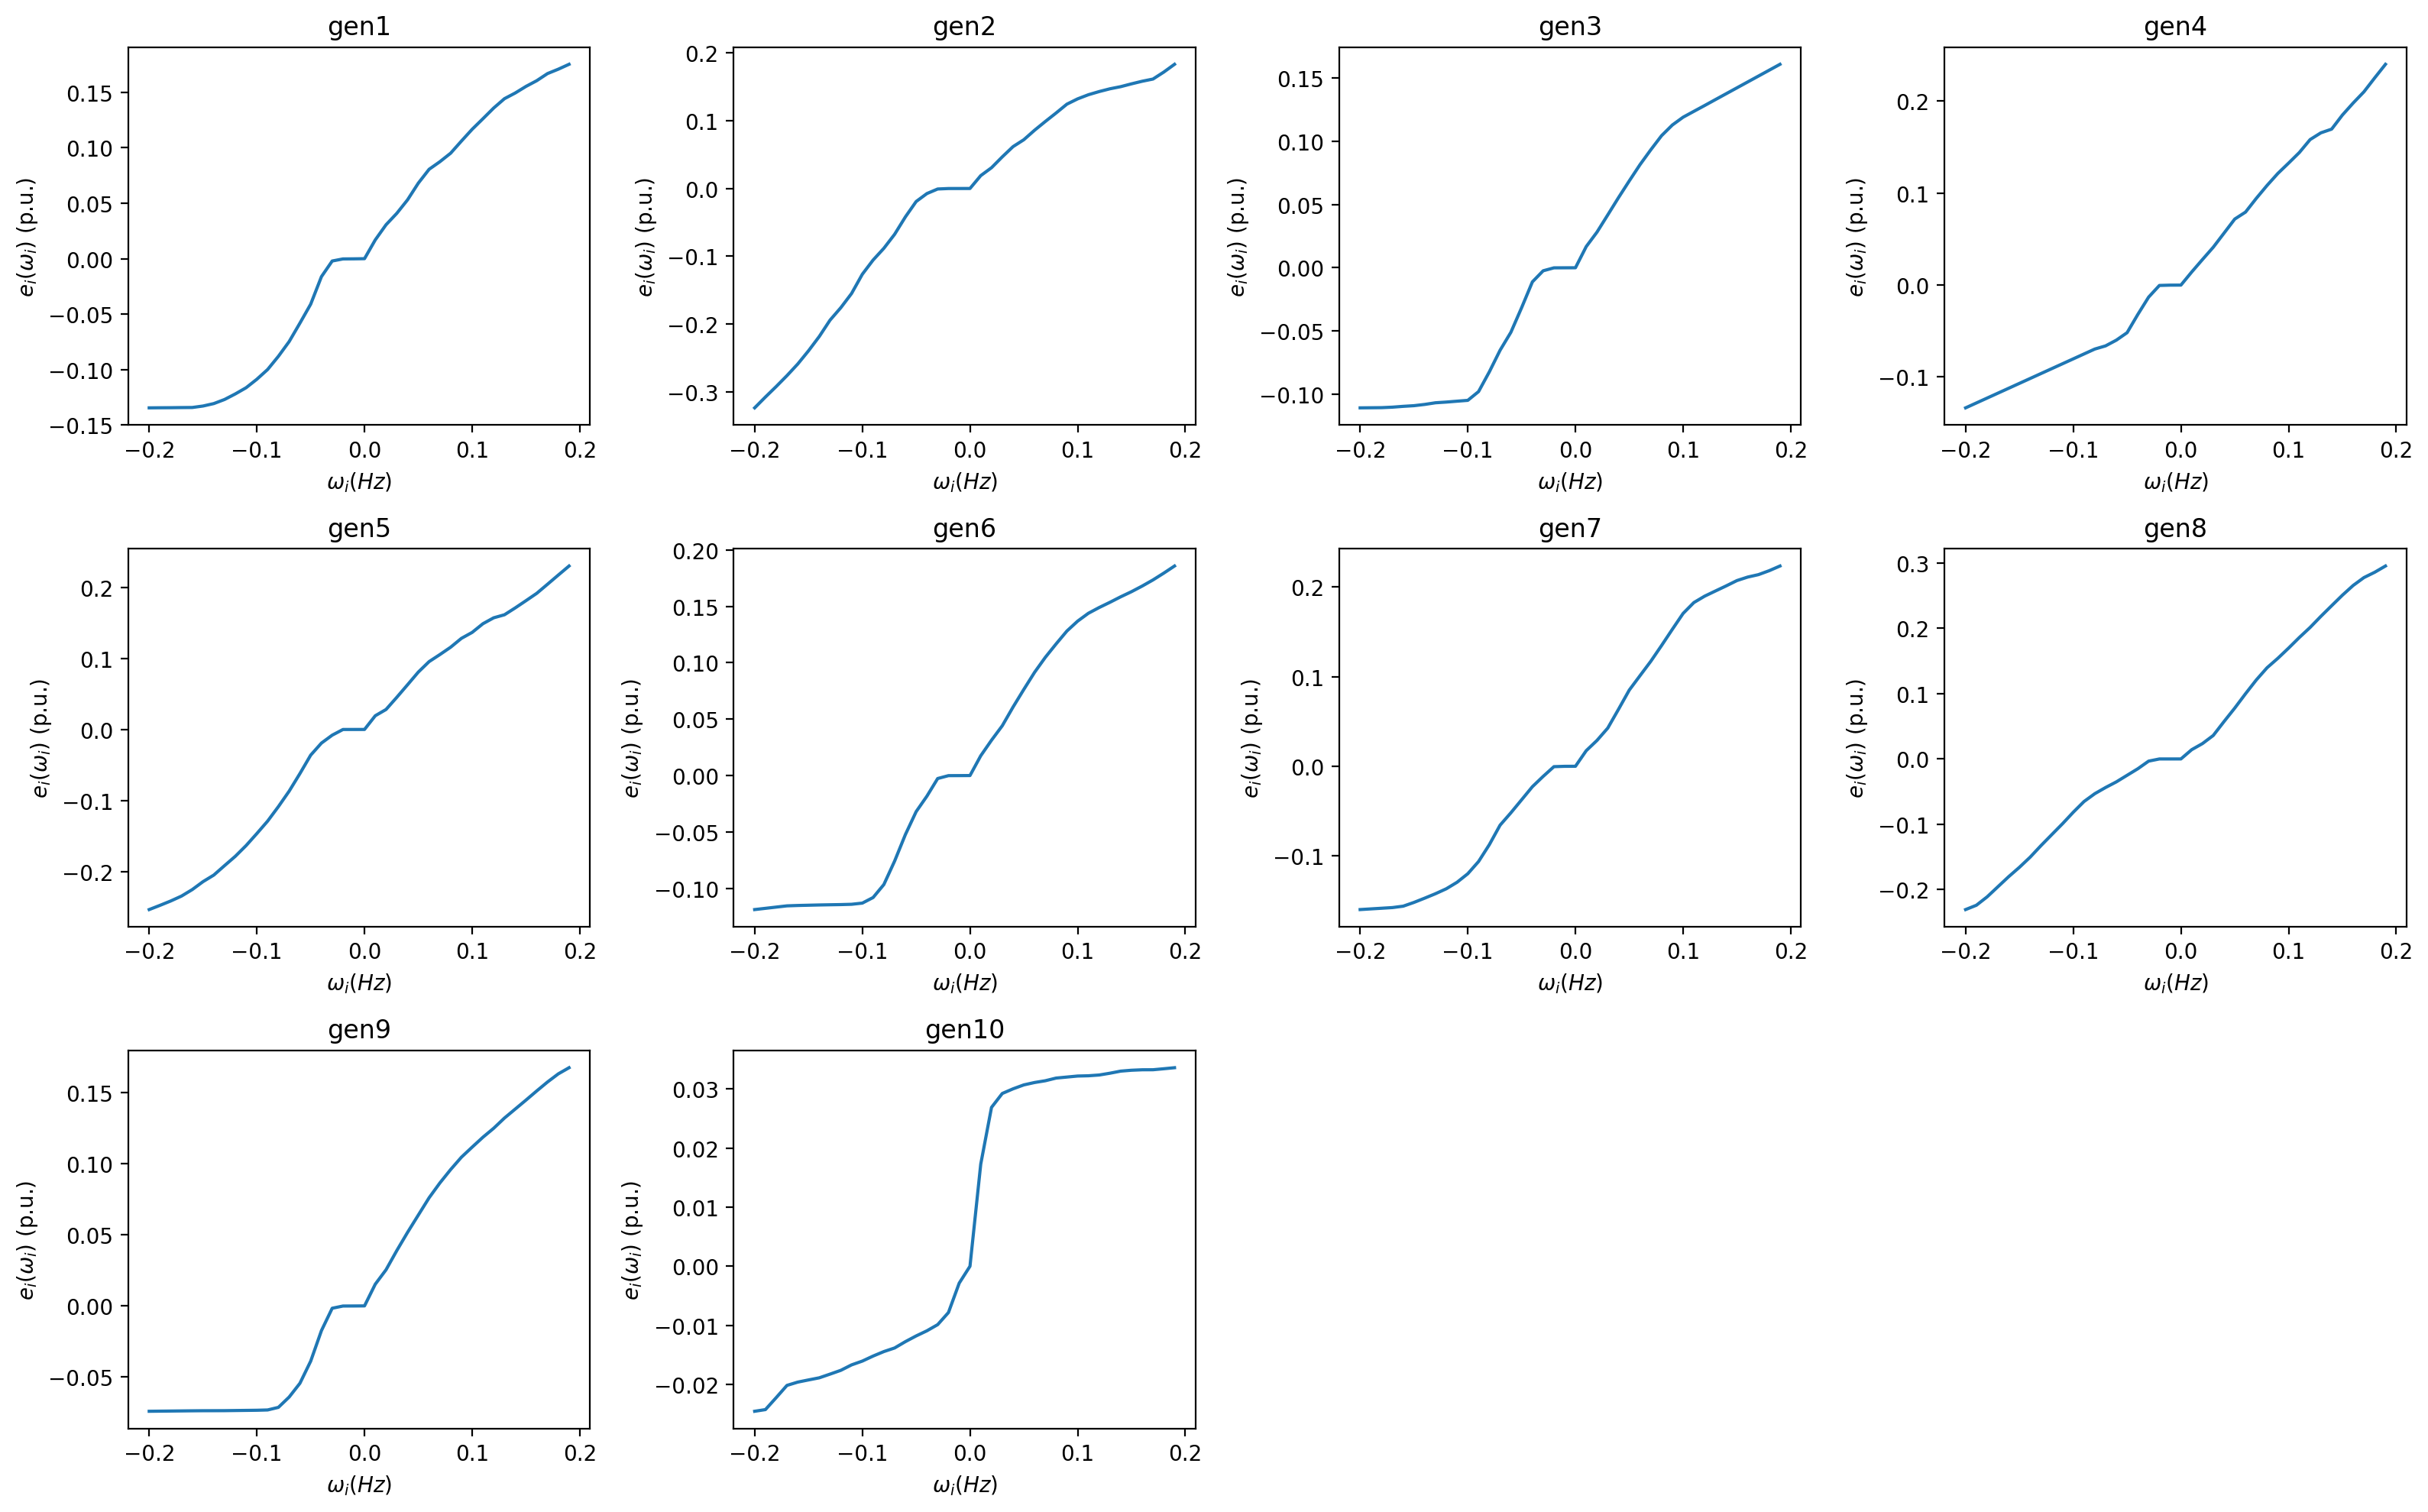

In [27]:
# plot the figures for action in selected buses


state_w=np.arange(-.2,.2,0.01,dtype=np.float32)
# state_d2=np.float32(0.03)
# state_w2=np.float32(0.02)

action_dw=np.zeros(len(state_w))
gen_idx_list=np.arange(dim_state)
fig=plt.figure(figsize=(16,10), dpi=200)
for idx_plot in range(len(gen_idx_list)):
    gen_idx=gen_idx_list[idx_plot]
    for j in range(len(state_w)):
            state_controlled=np.hstack((np.zeros((1,dim_state)),state_w[j]*np.ones((1,dim_state)),np.zeros((1,dim_state)),np.zeros((1,dim_state)),np.zeros((1,dim_state))))
            e,u=Action(state_controlled,env)
            action_dw[j]=e[0][gen_idx]
    plt.subplot(3,4,idx_plot+1)
    plt.plot(state_w,action_dw)
    plt.xlabel('$\omega_i (Hz)$')
    plt.ylabel('$e_i(\omega_i)$ (p.u.)')
    plt.title('gen'+str(gen_idx+1))
    # plt.legend(bbox_to_anchor=(0.98, 0.01), loc='lower right', borderaxespad=0.)
fig.tight_layout()